# Experiment 14: RNN Model for Stock Price Prediction


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, SimpleRNN, Dropout

## 2. Load Dataset

In [2]:
# Use your own CSV file if available
# Example:
# df = pd.read_csv("stock_prices.csv")

# Demo dataset
dates = pd.date_range(start="2020-01-01", periods=500, freq="D")
trend = np.linspace(100, 180, 500)
seasonal = 5 * np.sin(np.linspace(0, 20, 500))
noise = np.random.normal(0, 1.5, 500)

df = pd.DataFrame({
    "Date": dates,
    "Close": trend + seasonal + noise
})

df.head()

,Date,Close
0,2020-01-01,102.000887
1,2020-01-02,99.292853
2,2020-01-03,99.224487
3,2020-01-04,101.071362
4,2020-01-05,100.605659


## 3. Preprocess Data

In [3]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

data = df[["Close"]].values
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

scaled_data[:5]

array([[0.03176444],
       [0.00078216],
       [0.        ],
       [0.02112987],
       [0.01580182]])

## 4. Create Sequences

In [4]:
def create_sequences(dataset, time_step=60):
    X, y = [], []
    for i in range(time_step, len(dataset)):
        X.append(dataset[i-time_step:i, 0])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

time_step = 60
X, y = create_sequences(scaled_data, time_step)
X = X.reshape((X.shape[0], X.shape[1], 1))

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (440, 60, 1)
y shape: (440,)


## 5. Split Train and Test

In [5]:
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 352
Testing samples: 88


## 6. Build LSTM Model

In [6]:
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

model.compile(optimizer="adam", loss="mean_squared_error")
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Train Model

In [7]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - loss: 0.0548 - val_loss: 0.0038
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0103 - val_loss: 0.0235
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.0064 - val_loss: 0.0051
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.0047 - val_loss: 0.0043
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - loss: 0.0036 - val_loss: 0.0051
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0032 - val_loss: 7.8706e-04
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0030 - val_loss: 0.0017
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0024 - val_loss: 0.0023
Epoch 9/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0028 - val_loss: 6.6601e-04
Epoch 10/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0024 - val_loss: 5.8617e-04


## 8. Predict

In [8]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_pred = scaler.inverse_transform(train_pred)
test_pred = scaler.inverse_transform(test_pred)

y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step


## 9. Evaluate

## 9.5 Get Model Weights and Biases (Optional)

In [9]:
# Get the weights and biases from the trained model
weights_and_biases = model.get_weights()

# Print the number of weight/bias arrays and their shapes
print(f"Number of weight/bias arrays: {len(weights_and_biases)}")
for i, wb in enumerate(weights_and_biases):
    print(f"Array {i} shape: {wb.shape}")

# Example: Accessing the weights and biases of the first LSTM layer
# Note: The structure depends on your model architecture (e.g., LSTM layer has 3 weight matrices and 1 bias vector)
# For a Dense layer, it's typically 1 weight matrix and 1 bias vector.

# For the first LSTM layer (index 0, 1, 2, 3 correspond to kernel, recurrent_kernel, bias for LSTM and dropout)
# In Keras, a simple LSTM layer without return_sequences=True will have 3 weight matrices and 1 bias vector.
# If return_sequences=True, it has 3 weight matrices and 1 bias vector for the internal state.
# The order of weights depends on the layer type and its parameters.

# As an example, let's try to get the weights of the first Dense layer (index 4 for weights, 5 for bias in this model)
if len(weights_and_biases) >= 6:
    dense1_weights = weights_and_biases[4] # Weights for the first Dense layer
    dense1_biases = weights_and_biases[5]  # Biases for the first Dense layer

    print(f"\nShape of first Dense layer weights: {dense1_weights.shape}")
    print(f"Shape of first Dense layer biases: {dense1_biases.shape}")

# You can save these weights if needed, for example, using numpy.save
# import numpy as np
# np.save('dense1_weights.npy', dense1_weights)
# np.save('dense1_biases.npy', dense1_biases)

Number of weight/bias arrays: 10
Array 0 shape: (1, 200)
Array 1 shape: (50, 200)
Array 2 shape: (200,)
Array 3 shape: (50, 200)
Array 4 shape: (50, 200)
Array 5 shape: (200,)
Array 6 shape: (50, 25)
Array 7 shape: (25,)
Array 8 shape: (25, 1)
Array 9 shape: (1,)

Shape of first Dense layer weights: (50, 200)
Shape of first Dense layer biases: (200,)


In [10]:
rmse = np.sqrt(mean_squared_error(y_test_actual, test_pred))
mae = mean_absolute_error(y_test_actual, test_pred)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 2.116186655250708
MAE: 1.6916600674420834


## 10. Plot Results

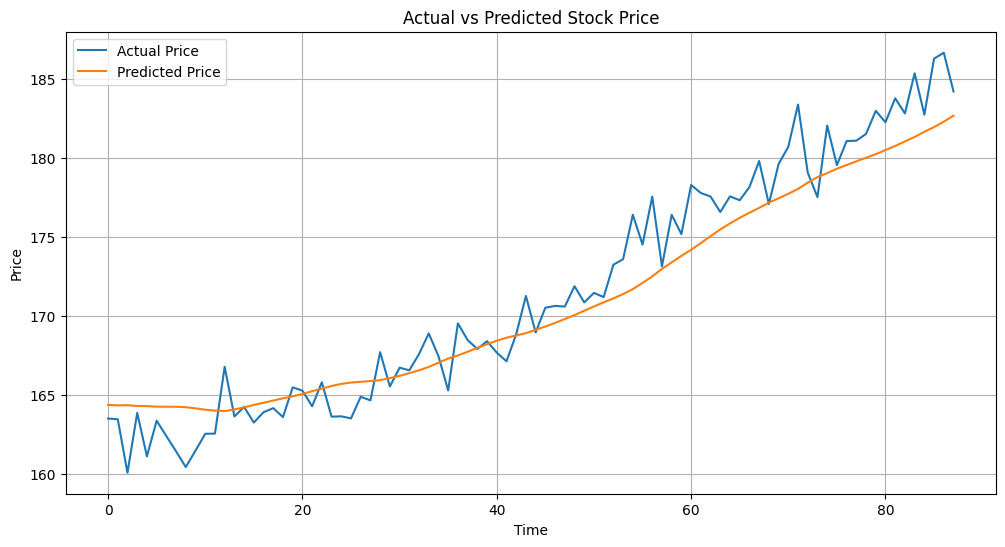

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label="Actual Price")
plt.plot(test_pred, label="Predicted Price")
plt.title("Actual vs Predicted Stock Price")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

## 11. Optional Simple RNN Model

In [12]:
simple_rnn_model = Sequential([
    SimpleRNN(50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    SimpleRNN(50),
    Dropout(0.2),
    Dense(1)
])

simple_rnn_model.compile(optimizer="adam", loss="mean_squared_error")
simple_rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 60, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)